Prerequisites
Before running this, ensure you have the libraries installed and the Tesseract engine installed on your system.

In [207]:
pip install opencv-python numpy pytesseract pillow matplotlib

Note: you may need to restart the kernel to use updated packages.


---------------------------------------------------------------------------------------------------------------------------------------

Imports and Configuration

In [208]:
import cv2
import numpy as np
import pytesseract
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt

# This helper function allows us to display images in the Notebook easily
def show_image(img, title="Image", cmap_type='gray'):
    plt.figure(figsize=(10, 8))
    plt.imshow(img, cmap=cmap_type)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Set your filename here
IMAGE_PATH = '/home/menas/Downloads/nade/best/PB120026.JPG'

Load and Convert to Grayscale
We start by loading the image. We convert BGR (OpenCV standard) to RGB for the plot, but we use the Grayscale version for processing.

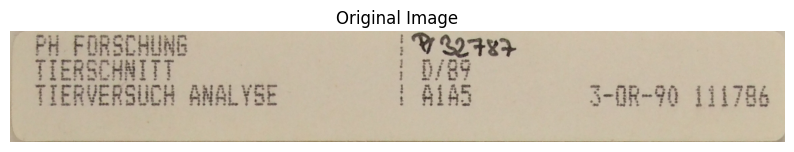

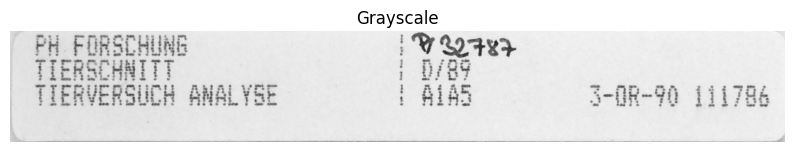

In [220]:
# Read image
original_img = cv2.imread(IMAGE_PATH)

if original_img is None:
    print(f"Error: Could not load image from {IMAGE_PATH}")
else:
    # Convert to grayscale for processing
    gray = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
    
    # Show original (converted to RGB for display)
    show_image(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB), "Original Image", cmap_type=None)
    show_image(gray, "Grayscale", cmap_type='gray')

Resize and Denoise
Dot-matrix dots can be mistaken for noise. We resize the image to make the dots larger and more distinct, then apply Non-Local Means Denoising to smooth out paper grain.

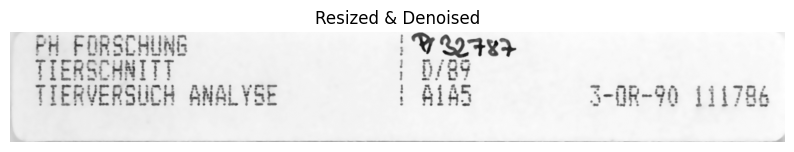

In [237]:
# Resize to optimal DPI (Scale up)
scale_percent = 150 # Adjust based on source DPI
width = int(gray.shape[1] * scale_percent / 100)
height = int(gray.shape[0] * scale_percent / 100)
resized = cv2.resize(gray, (width, height), interpolation=cv2.INTER_CUBIC)

# Denoise
# h=10 is the strength (higher = more blur/less noise)
denoised = cv2.fastNlMeansDenoising(resized, None, 20, 7, 21)

show_image(denoised, "Resized & Denoised")

Enhance Contrast (CLAHE)
We use CLAHE (Contrast Limited Adaptive Histogram Equalization) to make the faint ink stand out against the background.

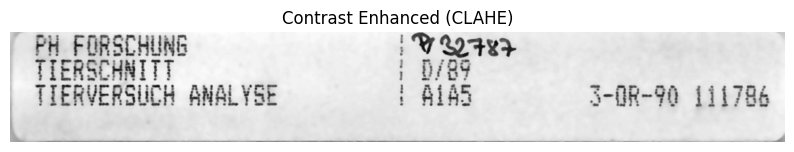

In [238]:
# Increase contrast using histogram equalization
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(3,3))
contrast = clahe.apply(denoised)

show_image(contrast, "Contrast Enhanced (CLAHE)")

Morphological Dilation (The "Dot Connector")
This is the most critical step for your label. We use dilation to make the white pixels (if inverted) or dark pixels "grow" so that the individual dots touch each other, forming solid letters.

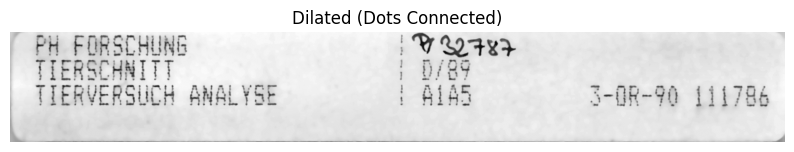

In [239]:
# Morphological operations to connect dots
# We use a small kernel. If dots are still separated, increase (2,2) to (3,3)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
dilated = cv2.dilate(contrast, kernel, iterations=1)

show_image(dilated, "Dilated (Dots Connected)")

Adaptive Thresholding
This converts the gray image into pure black and white.

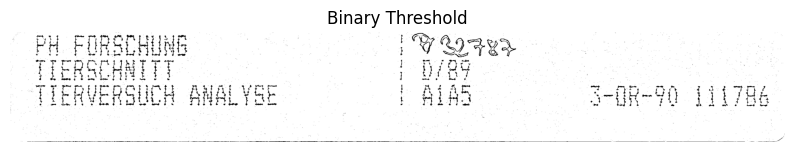

In [240]:
# Adaptive thresholding
binary = cv2.adaptiveThreshold(
    dilated, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=5,
    C=2
)

show_image(binary, "Binary Threshold")

Sharpening (via Pillow)
We switch briefly to PIL to apply a sharpening filter, which cleans up the edges of the now-binary text.

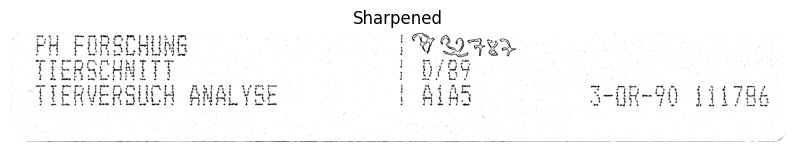

In [241]:
# Edge enhancement using PIL
pil_img = Image.fromarray(binary)
sharpened_pil = pil_img.filter(ImageFilter.SHARPEN)
sharpened = np.array(sharpened_pil)

show_image(sharpened, "Sharpened")

Deskewing (Rotation Correction)
Note: The original logic in your code np.where(array > 0) assumes the text is White on Black. Thresholding usually results in Black text on White. I added an inversion step (255 - sharpened) inside the calculation so the deskew logic tracks the ink, not the paper.

Final determined skew angle: 0.00 degrees


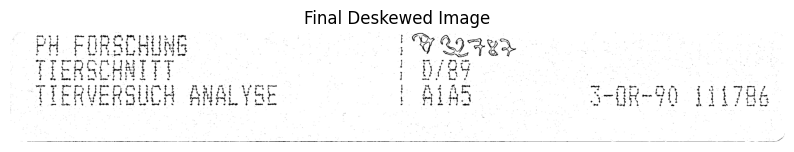

In [242]:

coords = np.column_stack(np.where((255 - sharpened) > 0))

# Get the center, dimensions (width, height), and angle of the minimum area rectangle
rect = cv2.minAreaRect(coords)
angle = rect[2]
(w, h) = rect[1]

# --- MANUAL ANGLE CORRECTION FOR WIDE IMAGES ---
# 1. Standardize angle to the range [0, -90]
if w < h:
    # If the bounding box width is less than height, angle is relative to the vertical axis.
    angle = angle - 90.0
    
# 2. Adjust angle to be the slight skew relative to horizontal (0 degrees)
if angle < -45:
    angle = -(90 + angle)
else:
    angle = -angle
# --- END MANUAL ANGLE CORRECTION ---


# --- CRITICAL FIX: IF WE DETECT A NEAR 90-DEGREE ROTATION, NULLIFY IT ---
# If the calculated angle is close to -90 or 90 degrees, it's an error. 
# We assume the image is horizontal and only correct very small skews.
# If the calculated angle is > 5 degrees, we manually set it to 0.
if abs(angle) > 5.0:
    angle = 0.0
# -----------------------------------------------------------------------


print(f"Final determined skew angle: {angle:.2f} degrees")

# Threshold: Only apply rotation if the angle is significant (e.g., > 2.0 degrees)
if abs(angle) > 2.0:
    (h_img, w_img) = sharpened.shape[:2]
    center = (w_img // 2, h_img // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    
    # Rotation logic for non-90/270 angles (maintains dimensions)
    final_image = cv2.warpAffine(
        sharpened, M, (w_img, h_img), 
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )
else:
    # If the angle is nearly 0, we skip rotation completely.
    final_image = sharpened

show_image(final_image, "Final Deskewed Image")

Run Tesseract OCR
Finally, we feed the processed image into Tesseract. Note: --psm 6 assumes a single uniform block of text, which matches your label perfectly.

In [245]:
# Configuration:
# --psm 6: Assume a single uniform block of text.
# --oem 3: Default OCR Engine Mode.
# Includes capital A-Z and digits 0-9
whitelist = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789/- " 
custom_config = f'--oem 3 --psm 6 -c tessedit_char_whitelist="{whitelist}" --dpi 150'
#custom_config = r'--psm 6 --oem 3 -c tessedit_char_whitelist="{whitelist}'

text = pytesseract.image_to_string(
    contrast,
    #lang='LCDDot_FT_500',  # Custom trained model for LCD/dot matrix
    lang='deu',  # Custom trained model for LCD/dot matrix
    config=custom_config
)

print("--- EXTRACTED TEXT ---")
print(text)
print("----------------------")


--- EXTRACTED TEXT ---
PH FORSCHUNG U FYF
TIERSCHNITT 0/89
TIERVERSUCH ANALYSE  AS 3-OR-90 111786

----------------------
